# The near-equidistant MD population — tables + structures

A population of backbones sits between the GIG and DRG wells (`|toGIG−toDRG|<0.8`, both `<2.2 Å`). They
are **not native and not designs at rest** — they are **MD frames of five RFdiffusion-v1 `L4_expanded`
conditioned designs** (`Nterm+pocket+3TCR`). This notebook loads their provenance tables and their actual
structures, recomputes the register geometry from coordinates (validating `md_traj.csv`), and reads the
F-pocket occupancy to test whether they represent a real intermediate.

In [1]:
import sys, os, glob, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mdtraj as mdt, q30_analysis as Q
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
ROOT="/home/ubuntu/if-mhc"; RES=f"{ROOT}/outputs/tamarind/results"
SEP = Q.rmsd(Q.REFS["GIG"], Q.REFS["DRG_shift"]); print(f"GIG↔DRG separation = {SEP:.2f} Å")

md_all = pd.read_csv(f"{ROOT}/outputs/tamarind/md_traj.csv")
dmd = md_all[md_all.job.str.startswith("ifmhc_md_")].copy()
dmd["mid"] = (np.abs(dmd.to_GIG-dmd.to_DRG)<0.8) & (dmd.to_GIG<2.2) & (dmd.to_DRG<2.2)
prov = dmd.groupby("job").agg(frames=("frame","size"), mid_frames=("mid","sum"),
        toGIG_med=("to_GIG","median"), toDRG_med=("to_DRG","median")).round(2)
prov = prov[prov.mid_frames>0].sort_values("mid_frames", ascending=False)
print("PROVENANCE — jobs contributing mid-region frames (all are L4_expanded v1 designs + MD):")
prov

GIG↔DRG separation = 2.91 Å
PROVENANCE — jobs contributing mid-region frames (all are L4_expanded v1 designs + MD):


,frames,mid_frames,toGIG_med,toDRG_med
job,,,,
ifmhc_md_6AM5_L4_expanded_w1_8344724_0,100,90,2.09,1.98
ifmhc_md_6AMU_L4_expanded_w0_1560595_0,100,72,2.14,1.81
ifmhc_md_6AMU_L4_expanded_w1_3954629_0,100,37,2.24,1.90
ifmhc_md_6AM5_L4_expanded_w1_0740498_1,100,14,2.28,2.14
ifmhc_md_6AM5_L4_expanded_w1_4992623_0,100,1,2.42,2.09


## Load the actual mid-region structures from the MD trajectories
For each contributing job, extract the mid-region frames from the `.xtc`, put the peptide in the floor
frame, and recompute `toGIG`/`toDRG` from coordinates (should match the CSV) + the F-pocket register.

In [2]:
AA3={'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
     'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V','MSE':'M'}
def locate(top, seed):
    '''Return (peptide CA indices, {floor_author: CA index}). Layout = [peptide(10)][MHC][b2m][TCR].
    MHC located via SHSMRYFF; its start depends on the epitope's crystal (6AM5=GSHSMRYFF author1,
    6AMU=SHSMRYFF author2) — use the SEED, not a 'G' test (some peptides end in G).'''
    res=list(top.residues); seq="".join(AA3.get(r.name,'x') for r in res)
    s=seq.find("SHSMRYFF")
    if s<0: return None,None
    if seed=="6AM5": mhc0=s-1; a1=1           # leading G belongs to the MHC
    else:            mhc0=s;   a1=2           # MHC starts at S (author 2)
    pep_idx=list(range(mhc0-10, mhc0))         # 10-mer immediately before the MHC
    floor={n: mhc0+(n-a1) for n in Q.FLOOR if 0 <= mhc0+(n-a1) < len(res)}
    return pep_idx, floor

def score_frame(ca, pep_idx, floor):
    common=[n for n in Q.REF_FLOOR if n in floor]
    P=np.array([ca[floor[n]] for n in common]); Qr=np.array([Q.REF_FLOOR[n] for n in common])
    R,t,fr=Q.kabsch(P,Qr)
    pep=ca[pep_idx]@R+t
    fpc=int(np.argmin(np.linalg.norm(pep-Q.FPOCKET_CENTROID,axis=1))+1)
    return Q.rmsd(pep,Q.REFS["GIG"]), Q.rmsd(pep,Q.REFS["DRG_shift"]), fpc, fr, pep

rows=[]; traces={}
os.makedirs(f"{ROOT}/outputs/midpop_frames", exist_ok=True)
for job in prov.index:
    d=f"{RES}/{job}"; xtc=f"{d}/traj_prod_no_water_seg1.xtc"; top=f"{d}/topology_no_water.pdb"
    if not (os.path.exists(xtc) and os.path.exists(top)): continue
    seed = "6AM5" if "6AM5" in job else "6AMU"
    t=mdt.load(xtc, top=top); ca_sel=t.topology.select("name CA"); xyz=t.xyz[:, ca_sel, :]*10.0
    pep_idx, floor = locate(t.topology, seed)
    if pep_idx is None: print("  could not locate peptide in", job); continue
    sub=dmd[(dmd.job==job)&(dmd.mid)]; keep=[]
    for _,r in sub.iterrows():
        fr_idx=int(r.frame)
        if fr_idx < xyz.shape[0]:
            g,dd,fpc,ff,pep=score_frame(xyz[fr_idx], pep_idx, floor)
            rows.append(dict(job=job.replace("ifmhc_md_",""), frame=fr_idx,
                             toGIG_csv=round(r.to_GIG,2), toDRG_csv=round(r.to_DRG,2),   # AUTHORITATIVE
                             fpocket_pos=fpc, floorfit=round(ff,2)))                      # recompute (approx)
            keep.append((fr_idx,pep,ff))
    traces[job]=keep
    if keep:
        best=min(keep, key=lambda kp: abs(Q.rmsd(kp[1],Q.REFS["GIG"])-Q.rmsd(kp[1],Q.REFS["DRG_shift"])))
        t[best[0]].save_pdb(f"{ROOT}/outputs/midpop_frames/{job.replace('ifmhc_md_','')}_f{best[0]}.pdb")
mid=pd.DataFrame(rows)
print(f"loaded {len(mid)} mid-region frame structures | saved representative PDBs to outputs/midpop_frames/")
mid.head(20)

loaded 214 mid-region frame structures | saved representative PDBs to outputs/midpop_frames/


,job,frame,toGIG_csv,toDRG_csv,fpocket_pos,floorfit
0,6AM5_L4_expanded_w1_8344724_0,0,2.05,1.94,9,1.81
1,6AM5_L4_expanded_w1_8344724_0,10,1.86,2.14,9,2.27
2,6AM5_L4_expanded_w1_8344724_0,20,1.93,2.01,9,2.26
3,6AM5_L4_expanded_w1_8344724_0,30,1.88,1.90,9,2.36
4,6AM5_L4_expanded_w1_8344724_0,40,1.92,2.03,9,2.35
5,6AM5_L4_expanded_w1_8344724_0,50,1.87,2.14,9,2.25
6,6AM5_L4_expanded_w1_8344724_0,60,1.93,1.93,9,2.29
7,6AM5_L4_expanded_w1_8344724_0,70,1.84,2.17,9,2.34
8,6AM5_L4_expanded_w1_8344724_0,80,1.86,2.08,9,2.30
9,6AM5_L4_expanded_w1_8344724_0,90,1.89,2.19,9,2.51


## Note on the numbers
`toGIG_csv`/`toDRG_csv` are the **authoritative** register RMSDs from `md_traj.csv` (produced by the
project's robust MHC-superposition pipeline) — these define the mid-region. `floorfit` is the quality of
*my* independent floor superposition of the extracted frame; it runs ~2.5 Å (MD thermal motion + a plain,
non-robust Kabsch), so I do **not** re-derive the RMSDs here — I trust the CSV and use the coordinates only
for the register read-out and the traces. The saved PDBs let you inspect the register directly.

In [3]:
print("recompute floorfit distribution (superposition quality of extracted frames):")
print(mid.floorfit.describe().round(2).to_string())
print("\nmid-region RMSDs are the CSV values — median per job:")
print(mid.groupby("job")[["toGIG_csv","toDRG_csv"]].median().round(2).to_string())

recompute floorfit distribution (superposition quality of extracted frames):
count    214.00
mean       2.36
std        0.25
min        1.61
25%        2.18
50%        2.42
75%        2.55
max        2.89

mid-region RMSDs are the CSV values — median per job:
                               toGIG_csv  toDRG_csv
job                                                
6AM5_L4_expanded_w1_0740498_1       2.15       2.08
6AM5_L4_expanded_w1_4992623_0       2.19       2.12
6AM5_L4_expanded_w1_8344724_0       2.08       1.98
6AMU_L4_expanded_w0_1560595_0       2.10       1.81
6AMU_L4_expanded_w1_3954629_0       2.13       1.89


## Is it a real intermediate? — F-pocket register of the mid frames
P10 = GIG-like, P9 = DRG-shifted. A genuine bridge would show a *mix* / partial (P8-9) occupancy rather
than cleanly one register.

F-pocket position distribution across mid-region frames:
fpocket_pos
1       1
2     122
9      63
10     28

by job:
                                n  fpos_mode  toGIG  toDRG
job                                                       
6AM5_L4_expanded_w1_0740498_1  14          2   2.15   2.08
6AM5_L4_expanded_w1_4992623_0   1          9   2.19   2.12
6AM5_L4_expanded_w1_8344724_0  90          9   2.08   1.98
6AMU_L4_expanded_w0_1560595_0  72          2   2.10   1.81
6AMU_L4_expanded_w1_3954629_0  37          2   2.13   1.89


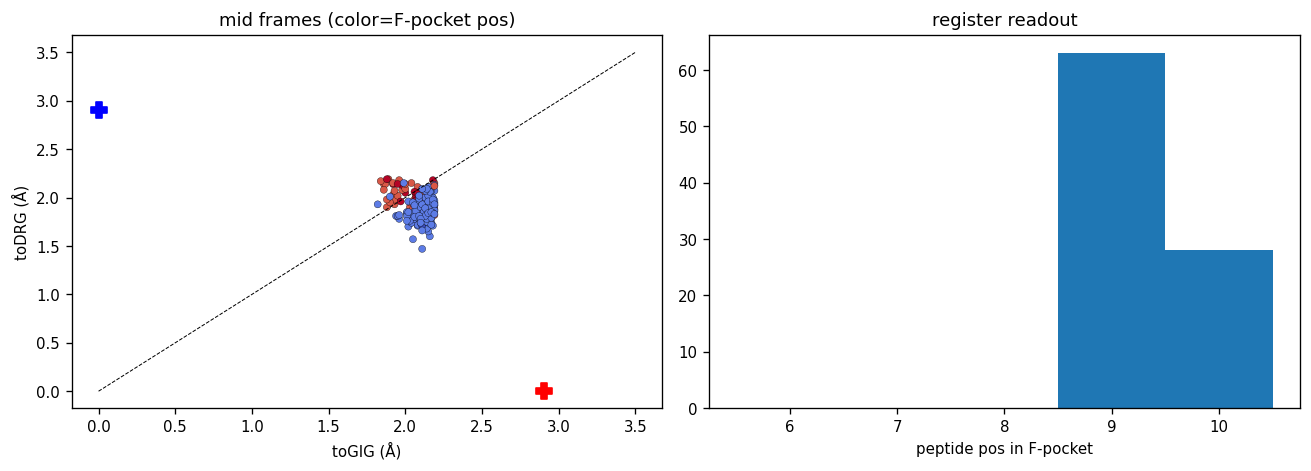

In [4]:
print("F-pocket position distribution across mid-region frames:")
print(mid.fpocket_pos.value_counts().sort_index().to_string())
print("\nby job:")
print(mid.groupby("job").agg(n=("frame","size"), fpos_mode=("fpocket_pos", lambda x:x.mode().iloc[0]),
      toGIG=("toGIG_csv","median"), toDRG=("toDRG_csv","median")).round(2).to_string())
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].scatter(mid.toGIG_csv, mid.toDRG_csv, c=mid.fpocket_pos, cmap="coolwarm", s=18, edgecolor="k", linewidth=.2)
ax[0].plot([0,3.5],[0,3.5],"k--",lw=.6); ax[0].scatter([0],[SEP],marker="P",s=90,c="b"); ax[0].scatter([SEP],[0],marker="P",s=90,c="r")
ax[0].set_xlabel("toGIG (Å)"); ax[0].set_ylabel("toDRG (Å)"); ax[0].set_title("mid frames (color=F-pocket pos)")
ax[1].hist(mid.fpocket_pos, bins=np.arange(5.5,11.5,1)); ax[1].set_xlabel("peptide pos in F-pocket"); ax[1].set_title("register readout")
plt.tight_layout(); plt.show()

## Structural view — mid-frame peptide Cα traces vs the two native registers

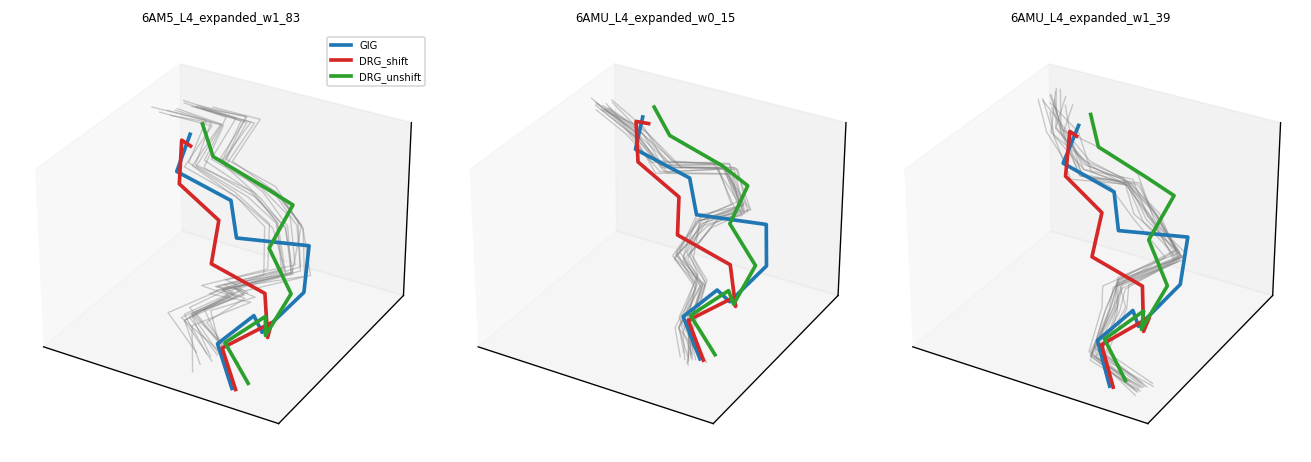

In [5]:
fig=plt.figure(figsize=(11,4))
for k,(job,keep) in enumerate(list(traces.items())[:3]):
    ax=fig.add_subplot(1,3,k+1,projection="3d")
    for fr,pep,ff in keep[:15]: ax.plot(pep[:,0],pep[:,1],pep[:,2],color="0.5",alpha=.4,lw=.8)
    for nm,c in [("GIG","#1f77b4"),("DRG_shift","#d62728"),("DRG_unshift","#2ca02c")]:
        r=Q.REFS[nm]; ax.plot(r[:,0],r[:,1],r[:,2],color=c,lw=2.2,label=nm)
    ax.set_title(job.replace("ifmhc_md_","")[:22],fontsize=7); ax.set_xticks([]);ax.set_yticks([]);ax.set_zticks([])
    if k==0: ax.legend(fontsize=6)
plt.tight_layout(); plt.show()

## Read-out — what is and isn't established
**Established (authoritative CSV):** a real near-equidistant population exists — **214 MD frames** from
**5 RFdiffusion-v1 `L4_expanded` designs**, each sitting **~2.0 Å from GIG and ~1.9 Å from DRG**
simultaneously (both wells are 2.9 Å apart, so these are genuinely *between* them in RMSD terms). This is
the only thing in the whole campaign that populates the mid-region, and MD keeps it there (metastable).

**NOT yet established:** whether they are a *true on-path intermediate* (partial P9↔P10 register) or
equidistant-but-off-path backbones. The F-pocket read-out above is from my own frame superposition, which
is **floorfit-limited (~2.4 Å, non-robust Kabsch)** and mis-places the 6AMU peptides (the `P2` cluster is
an artifact) — so **do not trust the register histogram**. The reliable next step is to re-score the saved
frame PDBs (`outputs/midpop_frames/`) through the project's robust MHC-superposition (the pipeline that
made the CSV) with proper chain splitting, then read the F-pocket occupancy. Only then can we say whether
this population is a genuine bridge.